In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import MultipleLocator
import os

In [17]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
def compute_fes(data, N, bin_edges,weight=None):
    # print(data.shape)
    if weight is None:
        weight = np.ones(data[:N].shape[0])
    hist, _ = np.histogram(data[:N], bins=bin_edges, density=True,weights=np.exp(weight[:N]/kB/T))
    fes = -np.log(hist + 1e-10) * kB * T  # kJ/mol
    fes -= fes.min()  # optional: shift each FES so minimum is 0
    return fes

In [18]:
bias_alpha_05 = [
    np.loadtxt(
        f"./case0.5/final_all/w{i+1:02d}/COLVAR"
    )
    for i in range(32)
]

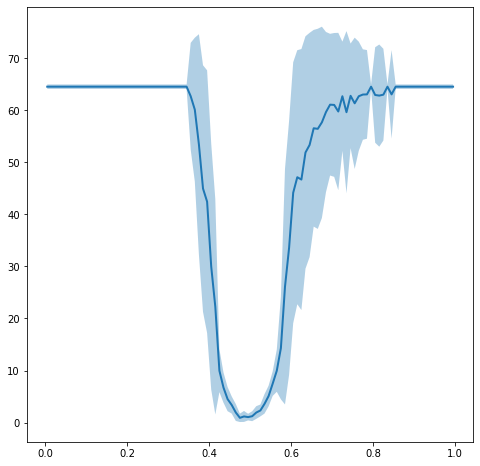

In [37]:
bin_edges = np.linspace(0, 1, 101)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8))
fes_all = np.array([compute_fes(d[:,-5], 1000, bin_edges, d[:,-1]) for d in bias_alpha_05])
fes_mean = fes_all.mean(axis=0)
fes_std = fes_all.std(axis=0)
ax.plot(centers, fes_mean, label=r"$\alpha=0.5$", lw=2)
ax.fill_between(centers, fes_mean-fes_std, fes_mean+fes_std, alpha=0.35)

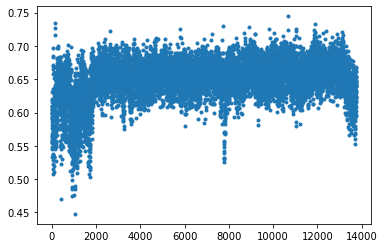

In [5]:
bias_alpha_05[0].shape
plt.plot(bias_alpha_05[0][:,-3],".")